In [55]:
import collections
from operator import concat

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib import pyplot as plt


plt.rcParams["figure.figsize"] = (10, 8)
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

data_train = pd.read_csv(DATA_PATH + "adult_train.csv", sep=";")
data_test = pd.read_csv(DATA_PATH + "adult_test.csv", sep=";")


In [56]:
data_train["Target"] = data_train["Target"].str.strip()
data_test["Target"] = data_test["Target"].str.strip()

data_test = data_test[
    (data_test["Target"] == ">50K") |
    (data_test["Target"] == "<=50K")
]

data_train["Target"] = data_train["Target"].map({
    "<=50K": 0,
    ">50K": 1
}).astype(int)

data_test["Target"] = data_test["Target"].map({
    "<=50K": 0,
    ">50K": 1
}).astype(int)

In [57]:
data_train

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [58]:
data_test.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Workclass,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Num,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Martial_Status,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Relationship,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
data_train["Target"].value_counts()

Target
0    24720
1     7841
Name: count, dtype: int64

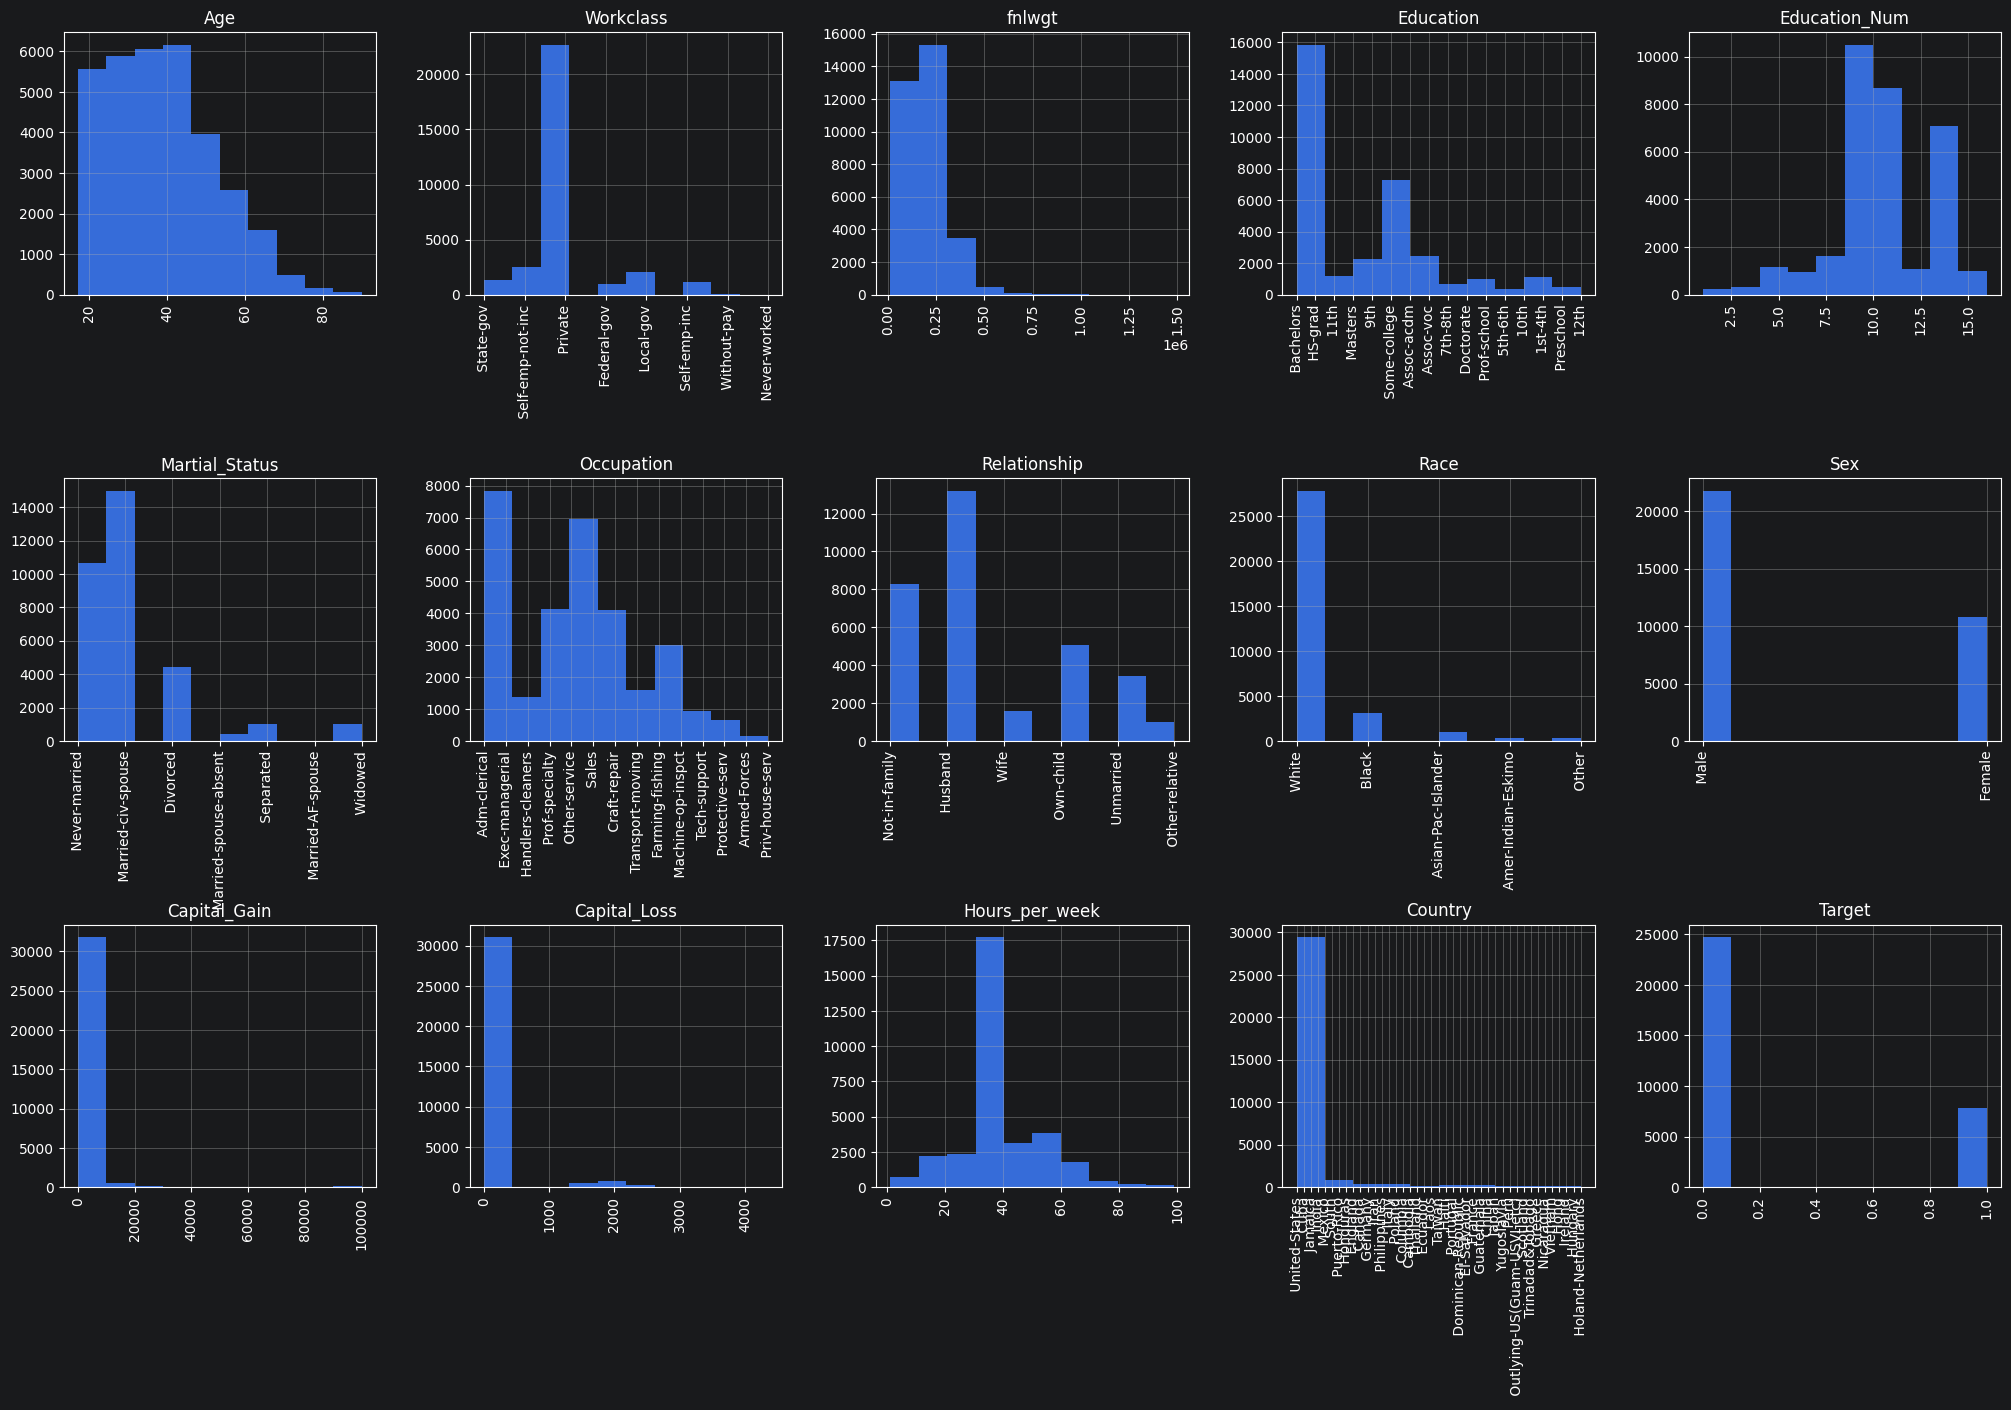

In [60]:
fig = plt.figure(figsize=(25,15))
cols = 5
rows = int(data_train.shape[1] / cols)
for i, column in enumerate(data_train.columns):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.set_title(column)
    if data_train[column].dtype == "object":
        data_train[column].value_counts().plot(kind="bar", ax=ax)
    else:
        data_train[column].hist(ax=ax)
        plt.xticks(rotation = "vertical")
plt.subplots_adjust(hspace=0.7, wspace=0.3)

In [61]:
data_train.dtypes


Age               int64
Workclass           str
fnlwgt            int64
Education           str
Education_Num     int64
Martial_Status      str
Occupation          str
Relationship        str
Race                str
Sex                 str
Capital_Gain      int64
Capital_Loss      int64
Hours_per_week    int64
Country             str
Target            int64
dtype: object

In [62]:
data_test.dtypes

Age                   str
Workclass             str
fnlwgt            float64
Education             str
Education_Num     float64
Martial_Status        str
Occupation            str
Relationship          str
Race                  str
Sex                   str
Capital_Gain      float64
Capital_Loss      float64
Hours_per_week    float64
Country               str
Target              int64
dtype: object

In [63]:
data_test["Age"] = data_test["Age"].astype(int)
data_train["Age"] = data_train["Age"].astype(int)

In [64]:
data_test["fnlwgt"] = data_test["fnlwgt"].astype(int)
data_test["Education_Num"] = data_test["Education_Num"].astype(int)
data_test["Capital_Gain"] = data_test["Capital_Gain"].astype(int)
data_test["Capital_Loss"] = data_test["Capital_Loss"].astype(int)
data_test["Hours_per_week"] = data_test["Hours_per_week"].astype(int)

In [65]:
y_train = data_train.pop('Target')
y_test = data_test.pop('Target')

In [66]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             32561 non-null  int64
 1   Workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   Education       32561 non-null  str  
 4   Education_Num   32561 non-null  int64
 5   Martial_Status  32561 non-null  str  
 6   Occupation      30718 non-null  str  
 7   Relationship    32561 non-null  str  
 8   Race            32561 non-null  str  
 9   Sex             32561 non-null  str  
 10  Capital_Gain    32561 non-null  int64
 11  Capital_Loss    32561 non-null  int64
 12  Hours_per_week  32561 non-null  int64
 13  Country         31978 non-null  str  
dtypes: int64(6), str(8)
memory usage: 3.5 MB


In [69]:
# choose categorical and continuous features from data

categorical_columns = [
    c for c in data_train.columns if data_train[c].dtype.name == "str"
]
numerical_columns = [
    c for c in data_train.columns if data_train[c].dtype.name != "object"
]

print("categorical_columns:", categorical_columns)
print("numerical_columns:", numerical_columns)

categorical_columns: ['Workclass', 'Education', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
numerical_columns: ['Age', 'Workclass', 'fnlwgt', 'Education', 'Education_Num', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week', 'Country']


In [70]:
data_train = pd.concat(
    [data_train[numerical_columns], pd.get_dummies(data_train[categorical_columns])],
    axis=1,
)
data_test = pd.concat(
    [data_test[numerical_columns], pd.get_dummies(data_test[categorical_columns])],
    axis=1,
)

In [71]:
set(data_train.columns) - set(data_test.columns)

{'Country_ Cambodia',
 'Country_ Canada',
 'Country_ China',
 'Country_ Columbia',
 'Country_ Cuba',
 'Country_ Dominican-Republic',
 'Country_ Ecuador',
 'Country_ El-Salvador',
 'Country_ England',
 'Country_ France',
 'Country_ Germany',
 'Country_ Greece',
 'Country_ Guatemala',
 'Country_ Haiti',
 'Country_ Holand-Netherlands',
 'Country_ Honduras',
 'Country_ Hong',
 'Country_ Hungary',
 'Country_ India',
 'Country_ Iran',
 'Country_ Ireland',
 'Country_ Italy',
 'Country_ Jamaica',
 'Country_ Japan',
 'Country_ Laos',
 'Country_ Mexico',
 'Country_ Nicaragua',
 'Country_ Outlying-US(Guam-USVI-etc)',
 'Country_ Peru',
 'Country_ Philippines',
 'Country_ Poland',
 'Country_ Portugal',
 'Country_ Puerto-Rico',
 'Country_ Scotland',
 'Country_ South',
 'Country_ Taiwan',
 'Country_ Thailand',
 'Country_ Trinadad&Tobago',
 'Country_ United-States',
 'Country_ Vietnam',
 'Country_ Yugoslavia',
 'Education_ 10th',
 'Education_ 11th',
 'Education_ 12th',
 'Education_ 1st-4th',
 'Educati